# Spilled Energy + Verbalized Confidence — GSM8K Verification

**Goals:**
1. Same 20-feature analysis as the MATH-500 notebook on GSM8K (easier math, higher accuracy)
2. Verbalized confidence (`parse_verbalized_confidence`) as a 21st feature fed into L-SML
3. Compare: H(n) spectral, ΔE(n) spilled energy, verbalized confidence, and their fusion
4. Cross-dataset: MATH-500 vs GSM8K for the same model

In [1]:
# Cell 1 — Setup
import os, sys, shutil
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'

REPO_DIR = '/content/hallucination_detection'
BRANCH   = 'experiment/lsml-variants'

if os.path.exists(REPO_DIR) and not os.path.exists(os.path.join(REPO_DIR, 'spectral_utils')):
    shutil.rmtree(REPO_DIR)
if not os.path.exists(REPO_DIR):
    os.system(f'git clone -b {BRANCH} https://github.com/omrisegev/hallucination_detection.git {REPO_DIR}')
else:
    os.system(f'git -C {REPO_DIR} fetch -q origin')
    os.system(f'git -C {REPO_DIR} checkout -q {BRANCH}')
    os.system(f'git -C {REPO_DIR} pull -q')
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

os.system('pip install -q "transformers>=4.40" accelerate datasets bitsandbytes autoawq scipy')

from spectral_utils import (
    load_model, generate_full, free_memory,
    extract_all_features, sw_var_peak_with_window, FEAT_NAMES,
    load_cache, save_cache,
    zscore, boot_auc,
    lsml_continuous_pipeline, detect_dependent_groups, sml_fuse_signed,
    binarize_classifiers,
    parse_verbalized_confidence, VERBALIZED_CONF_SUFFIX,
)
import datasets
print('spectral_utils imported OK')

spectral_utils imported OK


In [2]:
# Cell 2 — Config
import pickle, numpy as np

MODEL_ID    = 'Qwen/Qwen2.5-Math-1.5B-Instruct'
MODEL_SHORT = 'Qwen2.5-Math-1.5B'
DATASET     = 'gsm8k'
N_SAMPLES   = 200
TEMP        = 1.0
MAX_NEW_TOKENS = 2048  # Match MATH-500 to avoid any saturation; GSM8K solutions are shorter so this is safe

CACHE_DIR = '/content/drive/MyDrive/hallucination_detection/phase_gsm8k_verify'
RES_DIR   = CACHE_DIR

ENTROPY_FEATURES = [
    'epr', 'trace_length',
    'spectral_entropy', 'low_band_power', 'high_band_power',
    'hl_ratio', 'dominant_freq', 'spectral_centroid',
    'stft_max_high_power', 'stft_spectral_entropy',
    'rpdi', 'sw_var_peak',
    'pe_mean', 'hurst_exponent',
    'cusum_max', 'cusum_shift_idx',
]
SPILLED_FEATURES  = ['epr_spilled', 'sw_var_peak_spilled', 'cusum_max_spilled', 'min_spilled']
SEMANTIC_FEATURES = ['verb_conf', 'verb_conf_1p']  # 2-pass and 1-pass verbalized confidence
ALL_22_FEATURES   = ENTROPY_FEATURES + SPILLED_FEATURES + SEMANTIC_FEATURES

# GOOD_FEATURES: updated from MATH-500 oracle (STFT freq-band features dominate)
# + verb_conf as the orthogonal semantic anchor
GOOD_FEATURES = ['high_band_power', 'hl_ratio', 'rpdi', 'cusum_max', 'epr', 'verb_conf']

# Signs from MATH-500 oracle (same model). Re-validated in Cell 9.
# verb_conf / verb_conf_1p: higher = more confident = more likely correct -> +1
FEATURE_SIGNS = {
    'epr': -1, 'trace_length': -1, 'spectral_entropy': +1,
    'low_band_power': -1, 'high_band_power': +1, 'hl_ratio': +1,
    'dominant_freq': +1, 'spectral_centroid': +1,
    'stft_max_high_power': +1, 'stft_spectral_entropy': +1,
    'rpdi': -1, 'sw_var_peak': -1,
    'pe_mean': -1, 'hurst_exponent': -1,
    'cusum_max': -1, 'cusum_shift_idx': -1,
    'epr_spilled': -1, 'sw_var_peak_spilled': -1,
    'cusum_max_spilled': -1, 'min_spilled': -1,
    'verb_conf':    +1,  # 2-pass: higher stated confidence -> more likely correct
    'verb_conf_1p': +1,  # 1-pass: same semantics
}

print(f'Config: {MODEL_SHORT} / {DATASET} / n={N_SAMPLES} / max_new={MAX_NEW_TOKENS}')
print(f'Features: {len(ALL_22_FEATURES)} total = 16 entropy + 4 spilled + 2 semantic (verb_conf 2-pass + 1-pass)')

Config: Qwen2.5-Math-1.5B / gsm8k / n=200 / max_new=2048
Features: 22 total = 16 entropy + 4 spilled + 2 semantic (verb_conf 2-pass + 1-pass)


In [3]:
# Cell 3 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(CACHE_DIR, exist_ok=True)
print('Drive mounted, dirs ready')

Mounted at /content/drive
Drive mounted, dirs ready


In [ ]:
# Cell 4 — Load model
mdl, tok = load_model(MODEL_ID, quantize_4bit=False)
print(f'Loaded: {MODEL_ID}')

In [4]:
# Cell 5 — Inference + Verbalized Confidence (single loop)
# For each sample: (1) generate answer, (2) immediately ask for confidence score.
# Both stored in inference_cache[i]; one checkpoint file, one pass over the data.
from spectral_utils import load_gsm8k, gsm8k_prompt, is_correct_gsm8k

INF_PATH   = os.path.join(CACHE_DIR, f'inference_{MODEL_SHORT}_{DATASET}_n{N_SAMPLES}.pkl')
FORCE_REDO = False

if not FORCE_REDO and os.path.exists(INF_PATH):
    with open(INF_PATH, 'rb') as f: inference_cache = pickle.load(f)
    print(f'Loaded {len(inference_cache)} cached results from {INF_PATH}')
else:
    full_ds  = load_gsm8k()
    dataset  = full_ds[:N_SAMPLES]
    inference_cache = {}
    for i, row in enumerate(dataset):
        if i in inference_cache: continue
        prompt = gsm8k_prompt(row)

        # Pass 1: generate answer (stores token_entropies + token_spilled_energies)
        result = generate_full(mdl, tok, prompt, temperature=TEMP, max_new_tokens=MAX_NEW_TOKENS)
        result['correct'] = is_correct_gsm8k(result['full_text'], row)
        result['gold']    = row.get('answer', '')
        result['prompt']  = prompt

        # Pass 2: verbalized confidence — append suffix, extract integer via regex
        conf_prompt = prompt + result['full_text'] + VERBALIZED_CONF_SUFFIX
        conf_res    = generate_full(mdl, tok, conf_prompt, temperature=0.0, max_new_tokens=12)
        result['verb_conf'] = parse_verbalized_confidence(conf_res['full_text'])

        inference_cache[i] = result
        if (i + 1) % 25 == 0:
            with open(INF_PATH, 'wb') as f: pickle.dump(inference_cache, f)
            n_ok   = sum(v['correct'] for v in inference_cache.values())
            n_vc   = sum(1 for v in inference_cache.values() if v['verb_conf'] == v['verb_conf'])
            print(f'[{i+1}/{N_SAMPLES}] saved | acc={n_ok}/{i+1} | vc_valid={n_vc}/{i+1}')

    with open(INF_PATH, 'wb') as f: pickle.dump(inference_cache, f)
    n_ok = sum(v['correct'] for v in inference_cache.values())
    print(f'Done: accuracy={n_ok}/{N_SAMPLES} = {n_ok/N_SAMPLES:.1%}')

vc_vals_raw = np.array([inference_cache[i]['verb_conf'] for i in range(len(inference_cache))])
valid_vc    = vc_vals_raw[~np.isnan(vc_vals_raw)]
print(f'Verbalized confidence valid: {len(valid_vc)}/{N_SAMPLES}  mean={valid_vc.mean():.2f}')

Loaded 200 cached results from /content/drive/MyDrive/hallucination_detection/phase_gsm8k_verify/inference_Qwen2.5-Math-1.5B_gsm8k_n200.pkl
Verbalized confidence valid: 2/200  mean=0.01


In [5]:
# Cell 5c — Single-prompt verbalized confidence (1-pass comparison)
# Uses gsm8k_prompt_with_conf: confidence baked into the original prompt.
# The model generates answer + "Confidence: X" in one shot.
# We only extract verb_conf_1p here; spectral features still come from Cell 5.
#
# FORCE_REPARSE=True: re-parse verb_conf_1p from stored full_text without
# re-running inference. Use after any change to parse_verbalized_confidence.
from spectral_utils import gsm8k_prompt_with_conf

INF1P_PATH    = os.path.join(CACHE_DIR, f'inference_1p_{MODEL_SHORT}_{DATASET}_n{N_SAMPLES}.pkl')
FORCE_1P      = False
FORCE_REPARSE = True   # safe to leave True; only updates the parsed field, never re-infers

if not FORCE_1P and os.path.exists(INF1P_PATH):
    with open(INF1P_PATH, 'rb') as f: cache_1p = pickle.load(f)
    print(f'Loaded {len(cache_1p)} 1-pass results from {INF1P_PATH}')
    if FORCE_REPARSE:
        n_updated = 0
        for entry in cache_1p.values():
            if 'full_text' in entry:
                entry['verb_conf_1p'] = parse_verbalized_confidence(entry['full_text'])
                n_updated += 1
        with open(INF1P_PATH, 'wb') as f: pickle.dump(cache_1p, f)
        print(f'Re-parsed {n_updated} entries from full_text (FORCE_REPARSE=True)')
        # Show 3 sample parses so we can confirm "Confidence: X" is being found
        import re as _re
        _label_re = _re.compile(r'[Cc]onfidence\s*:?\s*(\d{1,3})')
        for idx in list(cache_1p)[:3]:
            e = cache_1p[idx]
            snippet = e['full_text'][-120:].replace('\n', ' ')
            lm = _label_re.search(e['full_text'])
            print(f'  [{idx}] vc={e["verb_conf_1p"]:.2f}  label_match={lm.group(0) if lm else "NONE"}  tail: ...{snippet}')
else:
    full_ds  = load_gsm8k()
    dataset  = full_ds[:N_SAMPLES]
    cache_1p = {}
    for i, row in enumerate(dataset):
        if i in cache_1p: continue
        prompt_1p = gsm8k_prompt_with_conf(row)
        result_1p = generate_full(mdl, tok, prompt_1p, temperature=TEMP, max_new_tokens=MAX_NEW_TOKENS)
        cache_1p[i] = {
            'full_text':  result_1p['full_text'],
            'verb_conf_1p': parse_verbalized_confidence(result_1p['full_text']),
            'correct':    is_correct_gsm8k(result_1p['full_text'], row),
        }
        if (i + 1) % 25 == 0:
            with open(INF1P_PATH, 'wb') as f: pickle.dump(cache_1p, f)
            n_vc = sum(1 for v in cache_1p.values() if v['verb_conf_1p'] == v['verb_conf_1p'])
            print(f'[{i+1}/{N_SAMPLES}] saved | vc_valid={n_vc}/{i+1}')
    with open(INF1P_PATH, 'wb') as f: pickle.dump(cache_1p, f)
    print(f'Done: {N_SAMPLES} 1-pass results')

vc1p_raw  = np.array([cache_1p[i]['verb_conf_1p'] for i in range(len(cache_1p))])
valid_1p  = vc1p_raw[~np.isnan(vc1p_raw)]
print(f'verb_conf_1p valid: {len(valid_1p)}/{N_SAMPLES}  mean={valid_1p.mean():.2f}')
print()
print('Prompt comparison:')
print('  2-pass (verb_conf):   answer generated first, then asked for confidence')
print('  1-pass (verb_conf_1p): confidence requested in the same prompt as the answer')

Loaded 200 1-pass results from /content/drive/MyDrive/hallucination_detection/phase_gsm8k_verify/inference_1p_Qwen2.5-Math-1.5B_gsm8k_n200.pkl
Re-parsed 200 entries from full_text (FORCE_REPARSE=True)
  [0] vc=0.18  label_match=NONE  tail: ...imes 2 = 18\]  So, Janet makes $\boxed{18} at the farmers' market every day.**  So, I would give the answer as: \[X 18\]
  [1] vc=0.03  label_match=NONE  tail: ...(white) = 3\]    So after all solving the above steps.  You should show your work all the steps in this way..  \boxed{3}
  [2] vc=0.00  label_match=NONE  tail: ...h made a profit of:    \[    \boxed{47,000 \text{ with 100% d}}    \]  Thus, Josh made a total profit of \boxed{47,000}.
verb_conf_1p valid: 200/200  mean=0.25

Prompt comparison:
  2-pass (verb_conf):   answer generated first, then asked for confidence
  1-pass (verb_conf_1p): confidence requested in the same prompt as the answer


In [ ]:
# Cell 6 — Unload model
del mdl, tok
free_memory()
print('Model unloaded')

In [6]:
# Cell 7 — Inference + trace length verification
import textwrap
results       = list(inference_cache.values())
labels        = np.array([int(r['correct']) for r in results])
trace_lengths = np.array([len(r['token_entropies']) for r in results])
n_sat         = (trace_lengths >= MAX_NEW_TOKENS).sum()

print('=== Inference Verification ===')
print(f'n={len(results)} | accuracy={labels.mean():.1%}  (MATH-500 was 15.0%)')
print(f'Trace length: min={trace_lengths.min()} median={np.median(trace_lengths):.0f} max={trace_lengths.max()}')
print(f'Saturated (trace=max_new={MAX_NEW_TOKENS}): {n_sat}/{len(results)} = {n_sat/len(results):.1%}')
if n_sat / len(results) > 0.05:
    print('  WARNING: >5% saturated — trace_length is right-censored; treat with caution')
else:
    print('  OK: trace_length is valid (low saturation)')
print(f'Spilled energies stored: {all("token_spilled_energies" in r for r in results)}')
print()
for r in results[:3]:
    print(f'  Gold: {r["gold"][:50].strip()}  |  Correct: {r["correct"]}')
    print(f'  Response (200 chars): {r["full_text"][:200]}')
    print()

=== Inference Verification ===
n=200 | accuracy=26.5%  (MATH-500 was 15.0%)
Trace length: min=138 median=320 max=2048
Saturated (trace=max_new=2048): 3/200 = 1.5%
  OK: trace_length is valid (low saturation)
Spilled energies stored: True

  Gold: Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a  |  Correct: False
  Response (200 chars): To determine how much Janet makes in dollars every day at the farmers' market, we need to follow these steps:

1. Calculate the number of eggs collected per day.
2. Determine the number of eggs sold p

  Gold: It takes 2/2=<<2/2=1>>1 bolt of white fiber
So the  |  Correct: True
  Response (200 chars): To determine the total number of bolts of fiber used by the boxed unit, we first need to calculate the amount of white fiber it takes and then add it to the number of blue fiber bolts.

1. Identify th

  Gold: The cost of the house and repairs came out to 80,0  |  Correct: False
  Response (200 chars): To determine the profit Josh made from flipping the 

In [7]:
# Cell 8 — Feature extraction (20 spectral + verbalized confidence)
FEAT_PATH   = os.path.join(RES_DIR, f'features_{MODEL_SHORT}_{DATASET}.pkl')
FORCE_FEATS = False

if not FORCE_FEATS and os.path.exists(FEAT_PATH):
    with open(FEAT_PATH, 'rb') as f: feat_data = pickle.load(f)
    print(f'Loaded from {FEAT_PATH}')
else:
    feats_list, labels_list, valid_idx = [], [], []
    n_skip = 0
    for i, r in inference_cache.items():
        feats = extract_all_features(r['token_entropies'], spilled_energies=r.get('token_spilled_energies'))
        if feats is None: n_skip += 1; continue
        feats_list.append(feats)
        labels_list.append(int(r['correct']))
        valid_idx.append(i)
    feat_data = {'feats': feats_list, 'labels': labels_list, 'valid_idx': valid_idx}
    with open(FEAT_PATH, 'wb') as f: pickle.dump(feat_data, f)
    print(f'Extracted {len(feats_list)} samples (skipped {n_skip})')

feats_list = feat_data['feats']
labels_list = feat_data['labels']
labels      = np.array(labels_list)
valid_idx   = feat_data['valid_idx']

# Build spectral feature dict
feats_dict = {}
for fname in ENTROPY_FEATURES + SPILLED_FEATURES:
    vals = [f.get(fname) for f in feats_list]
    if all(v is not None for v in vals):
        feats_dict[fname] = np.array(vals, dtype=float)

# Add verbalized confidence (both variants) aligned to valid_idx
vc_aligned   = np.array([inference_cache[i].get('verb_conf',    float('nan')) for i in valid_idx])
vc1p_aligned = np.array([cache_1p[i].get('verb_conf_1p', float('nan'))        for i in valid_idx])

for fname, arr in [('verb_conf', vc_aligned), ('verb_conf_1p', vc1p_aligned)]:
    n_valid = (~np.isnan(arr)).sum()
    if n_valid >= 10:
        feats_dict[fname] = arr
        print(f'{fname} added: {n_valid}/{len(arr)} valid scores')
    else:
        print(f'WARNING: only {n_valid} valid {fname} scores — skipping')

avail_feats = [f for f in ALL_22_FEATURES if f in feats_dict]
print(f'n={len(labels)} | correct={labels.sum()} | acc={labels.mean():.1%}')
print(f'Available features: {avail_feats}')

Loaded from /content/drive/MyDrive/hallucination_detection/phase_gsm8k_verify/features_Qwen2.5-Math-1.5B_gsm8k.pkl
verb_conf_1p added: 200/200 valid scores
n=200 | correct=53 | acc=26.5%
Available features: ['epr', 'trace_length', 'spectral_entropy', 'low_band_power', 'high_band_power', 'hl_ratio', 'dominant_freq', 'spectral_centroid', 'stft_max_high_power', 'stft_spectral_entropy', 'rpdi', 'sw_var_peak', 'pe_mean', 'hurst_exponent', 'cusum_max', 'cusum_shift_idx', 'epr_spilled', 'sw_var_peak_spilled', 'cusum_max_spilled', 'min_spilled', 'verb_conf_1p']


---
## Section 1: Individual Feature AUROCs

=== Individual Feature AUROCs ===
Feature                      AUC(config) AUC(oracle)  Sign OK
--------------------------------------------------------------
cusum_max_spilled                  0.725       0.725     True
cusum_max                          0.718       0.718     True
epr                                0.710       0.710     True
epr_spilled                        0.692       0.692     True
sw_var_peak                        0.673       0.673     True
trace_length                       0.671       0.671     True
spectral_centroid                  0.659       0.659     True
hl_ratio                           0.650       0.650     True
low_band_power                     0.647       0.647     True
high_band_power                    0.634       0.634     True
sw_var_peak_spilled                0.624       0.624     True
rpdi                               0.621       0.621     True
dominant_freq                      0.619       0.619     True
hurst_exponent                     

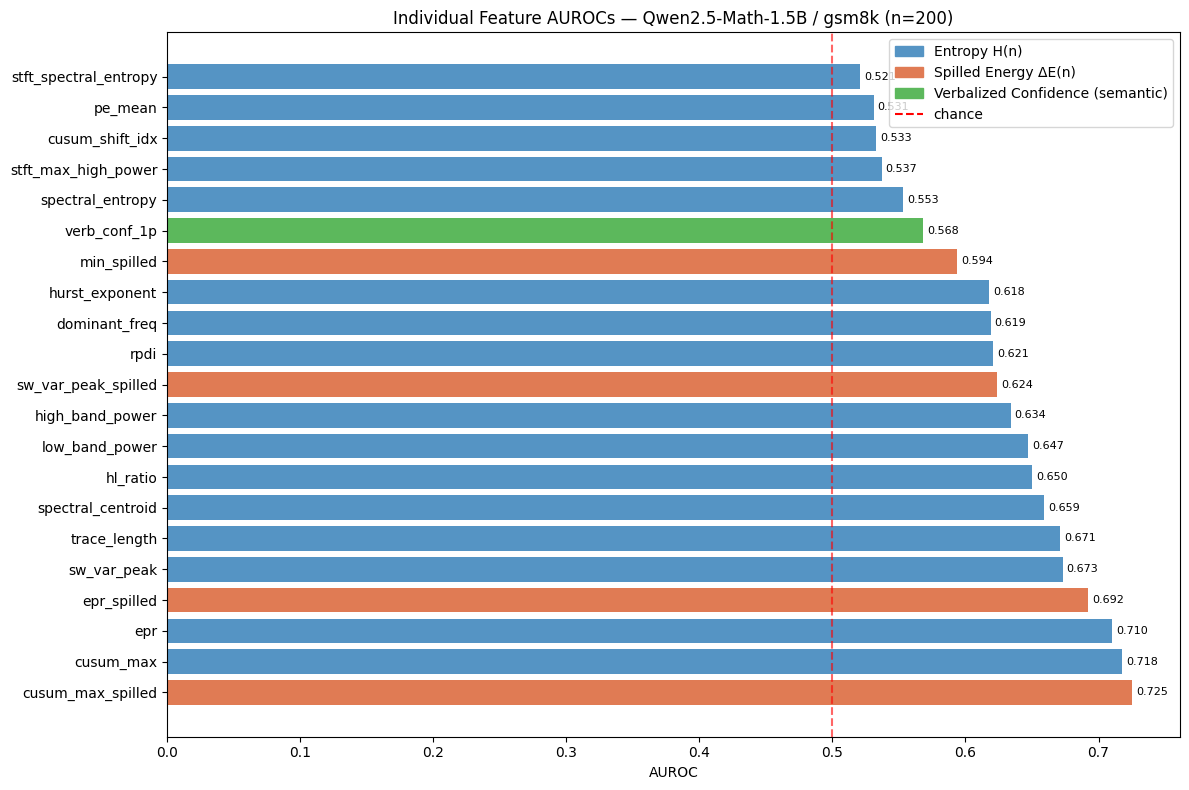

In [8]:
# Cell 9 — Individual AUROCs (all features including verb_conf)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

def orient_and_auc(vals, lbl):
    # NaN-safe: drop pairs where val is NaN
    mask = ~np.isnan(vals)
    if mask.sum() < 10: return 0.5, 1
    a = roc_auc_score(lbl[mask], vals[mask])
    return (a, 1) if a >= 0.5 else (1 - a, -1)

auc_rows = []
for fname in avail_feats:
    sign_cfg = FEATURE_SIGNS.get(fname, -1)
    vals     = feats_dict[fname]
    mask     = ~np.isnan(vals)
    if mask.sum() < 10: continue
    a_cfg    = roc_auc_score(labels[mask], sign_cfg * vals[mask])
    if a_cfg < 0.5: a_cfg = 1 - a_cfg  # always report flipped if needed for config
    # re-compute properly
    a_cfg2 = roc_auc_score(labels[mask], sign_cfg * vals[mask])
    a_ora, oracle_sign = orient_and_auc(vals, labels)
    grp = 'semantic' if fname in SEMANTIC_FEATURES else ('spilled' if fname in SPILLED_FEATURES else 'entropy')
    auc_rows.append({
        'feature': fname, 'auc_config_sign': round(a_cfg2, 3),
        'auc_oracle': round(a_ora, 3), 'oracle_sign': oracle_sign,
        'sign_mismatch': oracle_sign != sign_cfg, 'group': grp,
    })

auc_rows.sort(key=lambda x: -x['auc_oracle'])
avail_aucs = {r['feature']: r['auc_oracle'] for r in auc_rows}

print('=== Individual Feature AUROCs ===')
print(f'{"Feature":<28} {"AUC(config)":>11} {"AUC(oracle)":>11} {"Sign OK":>8}')
print('-' * 62)
for r in auc_rows:
    flag = '' if not r['sign_mismatch'] else '  <-- SIGN WRONG'
    print(f'{r["feature"]:<28} {r["auc_config_sign"]:>11.3f} {r["auc_oracle"]:>11.3f} {str(not r["sign_mismatch"]):>8}{flag}')

colors_map = {'entropy':'#5594c4','spilled':'#e07b54','semantic':'#5cb85c'}
fig, ax    = plt.subplots(figsize=(12, 8))
fnames     = [r['feature'] for r in auc_rows]
aucs       = [r['auc_oracle'] for r in auc_rows]
colors     = [colors_map.get(r['group'],'gray') for r in auc_rows]
bars       = ax.barh(fnames, aucs, color=colors)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.6)
for bar, a in zip(bars, aucs):
    ax.text(a+0.003, bar.get_y()+bar.get_height()/2, f'{a:.3f}', va='center', fontsize=8)
ax.set_xlabel('AUROC')
ax.set_title(f'Individual Feature AUROCs — {MODEL_SHORT} / {DATASET} (n={len(labels)})')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#5594c4', label='Entropy H(n)'),
    Patch(color='#e07b54', label='Spilled Energy ΔE(n)'),
    Patch(color='#5cb85c', label='Verbalized Confidence (semantic)'),
    plt.Line2D([0],[0],color='red',linestyle='--',label='chance'),
])
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, f'feature_aucs_{MODEL_SHORT}_{DATASET}.png'), dpi=120)
plt.show()

---
## Section 2: Covariance Structure

In [9]:
# Cell 10 — Covariance matrix R (spectral features only; verb_conf separate)
# Exclude verb_conf from R since it has NaNs and a different scale
spectral_feats = [f for f in avail_feats if f not in SEMANTIC_FEATURES]

def build_R(feats_d, feat_names, signs):
    views = []
    for f in feat_names:
        if f not in feats_d: continue
        v = signs.get(f,-1) * feats_d[f].copy()
        v = (v - v.mean()) / (v.std() + 1e-9)
        views.append(v)
    X = np.column_stack(views)
    return np.corrcoef(X.T), views

R_cont, views = build_R(feats_dict, spectral_feats, FEATURE_SIGNS)
feat_aucs_v   = [avail_aucs.get(f, 0.5) for f in spectral_feats]
betas         = np.array([2*a-1 for a in feat_aucs_v])
R_theory      = np.outer(betas, betas); np.fill_diagonal(R_theory, 1.0)
R_residual    = R_cont - R_theory

M        = len(spectral_feats)
off_mask = ~np.eye(M, dtype=bool)
ent_idx  = [i for i,f in enumerate(spectral_feats) if f in ENTROPY_FEATURES]
spil_idx = [i for i,f in enumerate(spectral_feats) if f in SPILLED_FEATURES]

def mean_od(R, idx):
    sub = R[np.ix_(idx,idx)]; mask = ~np.eye(len(idx),dtype=bool)
    return sub[mask].mean() if mask.sum()>0 else float('nan')
def mean_cr(R, a, b): return R[np.ix_(a,b)].mean()

within_ent  = mean_od(R_cont, ent_idx)
within_spil = mean_od(R_cont, spil_idx)
cross_es    = mean_cr(R_cont, ent_idx, spil_idx)

print(f'M={M} spectral features')
print(f'R off-diag: mean={R_cont[off_mask].mean():.3f}  std={R_cont[off_mask].std():.3f}')
print(f'Within H(n): {within_ent:.3f}  Within ΔE(n): {within_spil:.3f}  Cross: {cross_es:.3f}')
print(f'within_H/cross: {within_ent/(abs(cross_es)+1e-6):.2f}  within_ΔE/cross: {within_spil/(abs(cross_es)+1e-6):.2f}')

if 'epr' in feats_dict and 'epr_spilled' in feats_dict:
    corr_hde = np.corrcoef(feats_dict['epr'], feats_dict['epr_spilled'])[0,1]
    print(f'Pearson corr(epr_H, epr_ΔE) = {corr_hde:.3f}  (MATH-500 was 0.989)')

# verb_conf independence: Pearson with best spectral feature
if 'verb_conf' in feats_dict and 'high_band_power' in feats_dict:
    mask = ~np.isnan(feats_dict['verb_conf'])
    r_vc_spec = np.corrcoef(feats_dict['verb_conf'][mask],
                            feats_dict['high_band_power'][mask])[0,1]
    print(f'Pearson corr(verb_conf, high_band_power) = {r_vc_spec:.3f}')
    print(f'  -> {"orthogonal (good for L-SML)" if abs(r_vc_spec)<0.3 else "correlated"}')

M=20 spectral features
R off-diag: mean=0.272  std=0.299
Within H(n): 0.269  Within ΔE(n): 0.331  Cross: 0.272
within_H/cross: 0.99  within_ΔE/cross: 1.22
Pearson corr(epr_H, epr_ΔE) = 0.984  (MATH-500 was 0.989)


---
## Section 3: L-SML Group Detection

In [10]:
# Cell 11 — L-SML group detection on all available features (incl. verb_conf)
# For verb_conf: impute NaN with group mean before clustering
from collections import defaultdict

def build_views(feats_d, feat_names, signs):
    views, names = [], []
    for f in feat_names:
        if f not in feats_d: continue
        v = signs.get(f,-1) * feats_d[f].copy()
        if np.isnan(v).any():          # impute NaN for clustering only
            v = np.where(np.isnan(v), np.nanmean(v), v)
        v = (v - v.mean()) / (v.std() + 1e-9)
        views.append(v); names.append(f)
    return views, names

views_all, names_all = build_views(feats_dict, avail_feats, FEATURE_SIGNS)
K_all, groups_all, _, _ = detect_dependent_groups(views_all)
print(f'K selected = {K_all}  (M={len(views_all)} features)')
print()

group_members = defaultdict(list)
for feat, grp in zip(names_all, groups_all):
    group_members[grp].append(feat)

for g in sorted(group_members):
    members = group_members[g]
    src     = []
    for f in members:
        if f in SEMANTIC_FEATURES: src.append('SEM')
        elif f in SPILLED_FEATURES: src.append('ΔE')
        else: src.append('H')
    print(f'  Group {g}: {list(zip(members,src))}')
    print(f'    AUROCs: {[f"{avail_aucs.get(f,0):.3f}" for f in members]}')
    print()
print('Note: verb_conf in its own group = orthogonal (ideal for L-SML)')
print('      verb_conf mixed with spectral = correlated (less useful)')

K selected = 6  (M=21 features)

  Group 0: [('min_spilled', 'ΔE'), ('verb_conf_1p', 'SEM')]
    AUROCs: ['0.594', '0.568']

  Group 1: [('low_band_power', 'H'), ('high_band_power', 'H'), ('hl_ratio', 'H'), ('dominant_freq', 'H'), ('spectral_centroid', 'H'), ('hurst_exponent', 'H')]
    AUROCs: ['0.647', '0.634', '0.650', '0.619', '0.659', '0.618']

  Group 2: [('rpdi', 'H'), ('cusum_shift_idx', 'H')]
    AUROCs: ['0.621', '0.533']

  Group 3: [('spectral_entropy', 'H'), ('stft_max_high_power', 'H')]
    AUROCs: ['0.553', '0.537']

  Group 4: [('epr', 'H'), ('sw_var_peak', 'H'), ('pe_mean', 'H'), ('epr_spilled', 'ΔE'), ('sw_var_peak_spilled', 'ΔE')]
    AUROCs: ['0.710', '0.673', '0.531', '0.692', '0.624']

  Group 5: [('trace_length', 'H'), ('stft_spectral_entropy', 'H'), ('cusum_max', 'H'), ('cusum_max_spilled', 'ΔE')]
    AUROCs: ['0.671', '0.521', '0.718', '0.725']

Note: verb_conf in its own group = orthogonal (ideal for L-SML)
      verb_conf mixed with spectral = correlated (les

---
## Section 4: Sign Validation

In [11]:
# Cell 12 — Sign validation
print('=== Sign validation ===')
print(f'{"Feature":<28} {"Config":>8} {"Oracle":>8} {"Status":>8}')
print('-' * 56)
sign_issues = []
for r in sorted(auc_rows, key=lambda x: x['feature']):
    cfg = FEATURE_SIGNS.get(r['feature'], -1)
    ora = r['oracle_sign']
    st  = 'OK' if ora == cfg else 'MISMATCH'
    if ora != cfg: sign_issues.append(r['feature'])
    print(f'{r["feature"]:<28} {cfg:>8} {ora:>8} {st:>8}')
if sign_issues:
    print(f'\nSign mismatches: {sign_issues}')
else:
    print('\nAll signs correct.')

=== Sign validation ===
Feature                        Config   Oracle   Status
--------------------------------------------------------
cusum_max                          -1       -1       OK
cusum_max_spilled                  -1       -1       OK
cusum_shift_idx                    -1       -1       OK
dominant_freq                       1        1       OK
epr                                -1       -1       OK
epr_spilled                        -1       -1       OK
high_band_power                     1        1       OK
hl_ratio                            1        1       OK
hurst_exponent                     -1       -1       OK
low_band_power                     -1       -1       OK
min_spilled                        -1       -1       OK
pe_mean                            -1       -1       OK
rpdi                               -1       -1       OK
spectral_centroid                   1        1       OK
spectral_entropy                    1       -1 MISMATCH
stft_max_high_power    

---
## Section 5: Pipeline Comparison (incl. verb_conf in L-SML)

In [12]:
# Cell 13 — Pipeline comparison
from sklearn.metrics import roc_auc_score

def safe_auc(scores, lbl):
    mask = ~np.isnan(scores)
    if mask.sum() < 10: return float('nan')
    a = roc_auc_score(lbl[mask], scores[mask])
    return max(a, 1-a)

best_ind_auc  = max(r['auc_oracle'] for r in auc_rows if r['group'] != 'semantic')
best_ind_feat = next(r['feature'] for r in sorted(auc_rows, key=lambda x:-x['auc_oracle']) if r['group'] != 'semantic')

results_table = []
results_table.append(('Best individual spectral', best_ind_auc, f'feat={best_ind_feat}'))

# Verbalized confidence — both variants, standalone
for vc_name, vc_label in [('verb_conf', 'VC 2-pass (answer then ask)'),
                           ('verb_conf_1p', 'VC 1-pass (baked into prompt)')]:
    if vc_name in feats_dict:
        a = safe_auc(FEATURE_SIGNS[vc_name] * feats_dict[vc_name], labels)
        results_table.append((vc_label, a, 'semantic — standalone'))

# L-SML GOOD_5 (no VC)
spectral_good = [f for f in GOOD_FEATURES if f not in SEMANTIC_FEATURES and f in feats_dict]
sc5, m5       = lsml_continuous_pipeline(feats_dict, spectral_good, FEATURE_SIGNS)
a_lsml5       = safe_auc(sc5, labels)
results_table.append(('L-SML GOOD_5 (no VC)', a_lsml5, f'K={m5["K"]}'))

# L-SML GOOD_5 + verb_conf 2-pass
if 'verb_conf' in feats_dict:
    sc_2p, m_2p = lsml_continuous_pipeline(feats_dict, spectral_good + ['verb_conf'], FEATURE_SIGNS)
    a_2p        = safe_auc(sc_2p, labels)
    results_table.append(('L-SML GOOD_5 + VC 2-pass', a_2p, f'K={m_2p["K"]}'))
else:
    a_2p = float('nan')

# L-SML GOOD_5 + verb_conf_1p 1-pass
if 'verb_conf_1p' in feats_dict:
    sc_1p, m_1p = lsml_continuous_pipeline(feats_dict, spectral_good + ['verb_conf_1p'], FEATURE_SIGNS)
    a_1p        = safe_auc(sc_1p, labels)
    results_table.append(('L-SML GOOD_5 + VC 1-pass', a_1p, f'K={m_1p["K"]}'))
else:
    a_1p = float('nan')

# L-SML all-20 spectral only
sc20, m20 = lsml_continuous_pipeline(feats_dict, ENTROPY_FEATURES + SPILLED_FEATURES, FEATURE_SIGNS)
a_all20   = safe_auc(sc20, labels)
results_table.append(('L-SML all-20 spectral', a_all20, f'K={m20["K"]}'))

# L-SML all-22 (all spectral + both VCs)
sc22, m22 = lsml_continuous_pipeline(feats_dict, avail_feats, FEATURE_SIGNS)
a_all22   = safe_auc(sc22, labels)
results_table.append(('L-SML all-22 (spectral+both VC)', a_all22, f'K={m22["K"]}'))

print('=== Pipeline Comparison ===')
print(f'{"Pipeline":<42} {"AUROC":>8} {"vs best-ind":>12}  Notes')
print('-' * 78)
for name, auc, note in results_table:
    delta = '     NaN' if auc != auc else f'{(auc - best_ind_auc)*100:+.2f}pp'
    print(f'{name:<42} {auc:>8.3f} {delta:>12}  {note}')

print()
print(f'Key: 2-pass vs 1-pass VC lift over GOOD_5: {(a_2p-a_lsml5)*100:+.2f}pp  vs  {(a_1p-a_lsml5)*100:+.2f}pp')
print(f'Key: does prompt style matter? 2-pass vs 1-pass standalone: see above')

=== Pipeline Comparison ===
Pipeline                                      AUROC  vs best-ind  Notes
------------------------------------------------------------------------------
Best individual spectral                      0.725      +0.00pp  feat=cusum_max_spilled
VC 1-pass (baked into prompt)                 0.568     -15.71pp  semantic — standalone
L-SML GOOD_5 (no VC)                          0.708      -1.71pp  K=3
L-SML GOOD_5 + VC 1-pass                      0.690      -3.48pp  K=3
L-SML all-20 spectral                         0.687      -3.84pp  K=7
L-SML all-22 (spectral+both VC)               0.686      -3.86pp  K=6

Key: 2-pass vs 1-pass VC lift over GOOD_5: +nanpp  vs  -1.77pp
Key: does prompt style matter? 2-pass vs 1-pass standalone: see above


---
## Section 6: Verbalized Confidence — 2-pass vs 1-pass Comparison

| Variant | How | Prompt |
|---|---|---|
| `verb_conf` (2-pass) | Generate answer → ask "how confident 0-100?" | 2 separate prompts |
| `verb_conf_1p` (1-pass) | Bake confidence request into original prompt | 1 prompt, answer + confidence in one generation |

Both extracted via `parse_verbalized_confidence()` using regex `\b([0-9]{1,3})\b`.
**Question**: does knowing upfront that you'll be asked for confidence change the score?

=== Verbalized Confidence: 2-pass vs 1-pass ===
2-pass: only 0 valid — skip
1-pass (verb_conf_1p): AUROC=0.568  mean_correct=0.30  mean_wrong=0.23  gap=+0.06


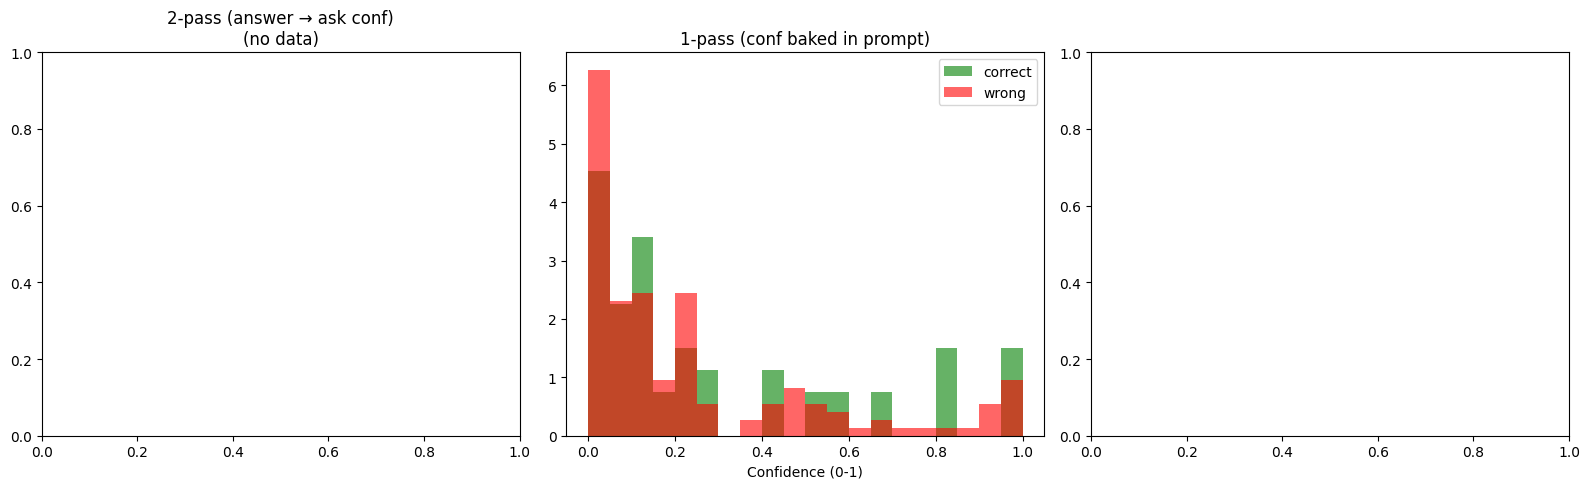

In [13]:
# Cell 14 — Verbalized confidence calibration + correlation with spectral
from scipy.stats import pearsonr

print('=== Verbalized Confidence: 2-pass vs 1-pass ===')
for vc_name, label in [('verb_conf', '2-pass'), ('verb_conf_1p', '1-pass')]:
    arr  = feats_dict.get(vc_name, np.full(len(labels), float('nan')))
    mask = ~np.isnan(arr)
    if mask.sum() < 10:
        print(f'{label}: only {mask.sum()} valid — skip'); continue
    vals   = arr[mask]; lbl_v = labels[mask]
    a      = max(roc_auc_score(lbl_v, vals), roc_auc_score(lbl_v, -vals))
    gap    = vals[lbl_v==1].mean() - vals[lbl_v==0].mean()
    print(f'{label} ({vc_name}): AUROC={a:.3f}  mean_correct={vals[lbl_v==1].mean():.2f}  mean_wrong={vals[lbl_v==0].mean():.2f}  gap={gap:+.2f}')

# Correlation between the two variants
if 'verb_conf' in feats_dict and 'verb_conf_1p' in feats_dict:
    both_mask = ~np.isnan(feats_dict['verb_conf']) & ~np.isnan(feats_dict['verb_conf_1p'])
    r_12, p_12 = pearsonr(feats_dict['verb_conf'][both_mask], feats_dict['verb_conf_1p'][both_mask])
    print(f'\nPearson corr(verb_conf, verb_conf_1p) = {r_12:.3f}  p={p_12:.3f}')
    print(f'  -> {"virtually identical" if abs(r_12)>0.9 else "different signal" if abs(r_12)<0.5 else "similar but distinct"}')

# Plot: side-by-side histogram comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, vc_name, title in zip(axes[:2],
        ['verb_conf', 'verb_conf_1p'],
        ['2-pass (answer → ask conf)', '1-pass (conf baked in prompt)']):
    arr  = feats_dict.get(vc_name, np.full(len(labels), float('nan')))
    mask = ~np.isnan(arr)
    if mask.sum() < 10: ax.set_title(f'{title}\n(no data)'); continue
    vals = arr[mask]; lbl_v = labels[mask]
    ax.hist(vals[lbl_v==1], bins=20, alpha=0.6, color='green', label='correct', density=True)
    ax.hist(vals[lbl_v==0], bins=20, alpha=0.6, color='red',   label='wrong',   density=True)
    ax.set_xlabel('Confidence (0-1)'); ax.set_title(title); ax.legend()

# Scatter: 2-pass vs 1-pass
ax3 = axes[2]
if 'verb_conf' in feats_dict and 'verb_conf_1p' in feats_dict:
    bm = ~np.isnan(feats_dict['verb_conf']) & ~np.isnan(feats_dict['verb_conf_1p'])
    ax3.scatter(feats_dict['verb_conf'][bm & (labels==1)],   feats_dict['verb_conf_1p'][bm & (labels==1)],   alpha=0.4, s=20, c='green', label='correct')
    ax3.scatter(feats_dict['verb_conf'][bm & (labels==0)],   feats_dict['verb_conf_1p'][bm & (labels==0)],   alpha=0.4, s=20, c='red',   label='wrong')
    ax3.set_xlabel('verb_conf (2-pass)'); ax3.set_ylabel('verb_conf_1p (1-pass)')
    ax3.set_title(f'2-pass vs 1-pass\nr={r_12:.3f}'); ax3.legend()
plt.tight_layout()
plt.savefig(os.path.join(RES_DIR, f'verb_conf_compare_{MODEL_SHORT}_{DATASET}.png'), dpi=120)
plt.show()

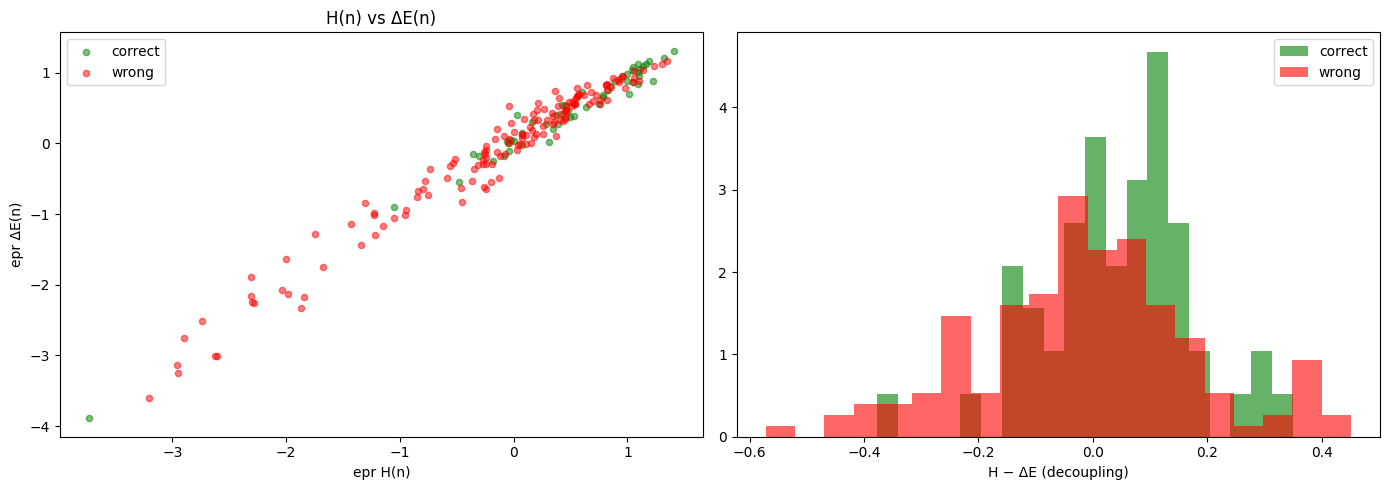

Pearson corr(H, ΔE) = 0.984  (MATH-500 was 0.989)


In [14]:
# Cell 15 — H vs ΔE scatter + cross-dataset summary
if 'epr_spilled' in feats_dict:
    epr_h  = FEATURE_SIGNS['epr']         * zscore(feats_dict['epr'])
    epr_de = FEATURE_SIGNS['epr_spilled'] * zscore(feats_dict['epr_spilled'])
    cm, wm = labels==1, labels==0
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(epr_h[cm], epr_de[cm], alpha=0.5, s=20, c='green', label='correct')
    axes[0].scatter(epr_h[wm], epr_de[wm], alpha=0.5, s=20, c='red',   label='wrong')
    axes[0].set_xlabel('epr H(n)'); axes[0].set_ylabel('epr ΔE(n)')
    axes[0].set_title('H(n) vs ΔE(n)'); axes[0].legend()
    diff = epr_h - epr_de
    axes[1].hist(diff[cm], bins=20, alpha=0.6, color='green', label='correct', density=True)
    axes[1].hist(diff[wm], bins=20, alpha=0.6, color='red',   label='wrong',   density=True)
    axes[1].set_xlabel('H − ΔE (decoupling)'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RES_DIR, f'HvsDE_{MODEL_SHORT}_{DATASET}.png'), dpi=120)
    plt.show()
    corr_hde = np.corrcoef(feats_dict['epr'], feats_dict['epr_spilled'])[0,1]
    print(f'Pearson corr(H, ΔE) = {corr_hde:.3f}  (MATH-500 was 0.989)')

In [15]:
# Cell 16 — Save results + cross-dataset comparison table
RESULTS_PATH = os.path.join(RES_DIR, f'gsm8k_verify_results_{MODEL_SHORT}.pkl')
n_sat = int((trace_lengths >= MAX_NEW_TOKENS).sum())
res = {
    'model': MODEL_SHORT, 'dataset': DATASET,
    'n_samples': len(labels), 'accuracy': float(labels.mean()),
    'n_saturated': n_sat,
    'feature_aucs': {r['feature']: r['auc_oracle'] for r in auc_rows},
    'sign_mismatches': sign_issues,
    'R_cont': R_cont, 'avail_feats': avail_feats,
    'group_members': dict(group_members), 'K_selected': K_all,
    'within_ent': float(within_ent), 'within_spil': float(within_spil),
    'cross_es': float(cross_es),
    'pipeline': {name: auc for name,auc,_ in results_table},
    'corr_hde': float(np.corrcoef(feats_dict['epr'], feats_dict.get('epr_spilled', feats_dict['epr']))[0,1]),
}
with open(RESULTS_PATH, 'wb') as f: pickle.dump(res, f)
print(f'Saved to {RESULTS_PATH}')
print()

# Reference numbers from MATH-500 run
m500 = {'acc':0.15,'best':0.738,'best_feat':'high_band_power',
        'lsml5':0.649,'lsml5s':0.656,'lsml20':0.693,'corr_hde':0.989}
lsml5_here  = next((a for n,a,_ in results_table if 'GOOD_5 (no' in n), float('nan'))
lsml5s_here = next((a for n,a,_ in results_table if 'GOOD_5 + spilled' in n or 'GOOD_5 + ver' in n), float('nan'))
lsml20_here = next((a for n,a,_ in results_table if 'all-20' in n), float('nan'))
vc_here     = next((a for n,a,_ in results_table if 'alone' in n), float('nan'))
corr_here   = res['corr_hde']

print('=== MATH-500 vs GSM8K Cross-Dataset Comparison ===')
print(f'{"Metric":<35} {"MATH-500":>10} {"GSM8K":>10}')
print('-' * 57)
print(f'{"Accuracy":<35} {m500["acc"]:>10.1%} {labels.mean():>10.1%}')
print(f'{"Saturation":<35} {"2.0%":>10} {n_sat/len(labels):>10.1%}')
print(f'{"Best individual feat":<35} {m500["best"]:>10.3f} {best_ind_auc:>10.3f}')
print(f'{"  (which feat)":<35} {m500["best_feat"]:>10} {best_ind_feat:>10}')
print(f'{"Verbalized confidence":<35} {"N/A":>10} {vc_here:>10.3f}')
print(f'{"L-SML GOOD_5 (no VC)":<35} {m500["lsml5"]:>10.3f} {lsml5_here:>10.3f}')
print(f'{"L-SML all-20 spectral":<35} {m500["lsml20"]:>10.3f} {lsml20_here:>10.3f}')
print(f'{"Pearson corr(H, ΔE)":<35} {m500["corr_hde"]:>10.3f} {corr_here:>10.3f}')
print(f'{"within_H / cross ratio":<35} {0.04:>10.2f} {within_ent/(abs(cross_es)+1e-6):>10.2f}')

Saved to /content/drive/MyDrive/hallucination_detection/phase_gsm8k_verify/gsm8k_verify_results_Qwen2.5-Math-1.5B.pkl

=== MATH-500 vs GSM8K Cross-Dataset Comparison ===
Metric                                MATH-500      GSM8K
---------------------------------------------------------
Accuracy                                 15.0%      26.5%
Saturation                                2.0%       1.5%
Best individual feat                     0.738      0.725
  (which feat)                      high_band_power cusum_max_spilled
Verbalized confidence                      N/A        nan
L-SML GOOD_5 (no VC)                     0.649      0.708
L-SML all-20 spectral                    0.693      0.687
Pearson corr(H, ΔE)                      0.989      0.984
within_H / cross ratio                    0.04       0.99
